In [8]:
import pandas as pd

# Carga tu archivo
df = pd.read_csv('TelecomX_Data_Clean.csv')

# Revisa las primeras filas
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Cargar datos
df = pd.read_csv('TelecomX_Data_Clean.csv')

# 2. Eliminar basura (ID no predice nada)
df.drop(columns=['customerID'], inplace=True)

# 3. Encoding AUTOMÁTICO (Convierte todo el texto a números de un solo golpe)
df_final = pd.get_dummies(df)

# 4. Separar X (características) de y (lo que queremos predecir: Churn)
# Nota: Como get_dummies crea columnas, buscamos la de Churn_Yes
X = df_final.drop(columns=['Churn_Yes', 'Churn_No'])
y = df_final['Churn_Yes']

# 5. Split: 80% entrena, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("¡Datos listos para el modelo!")

¡Datos listos para el modelo!


**Verificación de la Proporción de Cancelación (Churn)**

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.


Churn_Yes
False    0.73463
True     0.26537
Name: proportion, dtype: float64


<Axes: title={'center': 'Proporción de Churn (0=No, 1=Sí)'}, xlabel='Churn_Yes'>

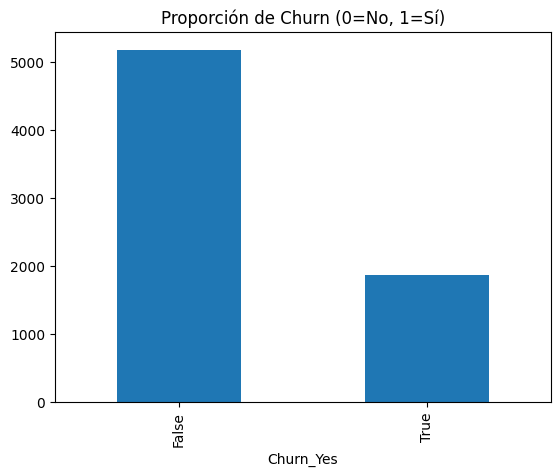

In [10]:
# Ver cuántos se van (1) y cuántos se quedan (0)
print(y.value_counts(normalize=True))

# Visualización rápida
y.value_counts().plot(kind='bar', title='Proporción de Churn (0=No, 1=Sí)')

**Eliminación de Columnas Irrelevantes**

Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [13]:
# Eliminando la columna que no aporta valor predictivo
df.drop(columns=['customerID'], inplace=True, errors='ignore')

Balanceo de Clases (opcional) **bold text**

Si deseas profundizar en el análisis, aplica técnicas de balanceo como undersampling o oversampling. En situaciones de fuerte desbalanceo, herramientas como SMOTE pueden ser útiles para generar ejemplos sintéticos de la clase minoritaria.

In [ ]:
# !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smt = SMOTE(random_state=42)
X_res, y_res = smt.fit_resample(X, y)

# Ahora dividimos con los datos ya balanceados
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

print("¡Datos balanceados y listos!")

**Normalización o Estandarización (si es necesario)**

Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Solo escalamos las X (las características)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("¡Datos normalizados y listos para el entrenamiento!")

 **Correlación y Selección de Variables**

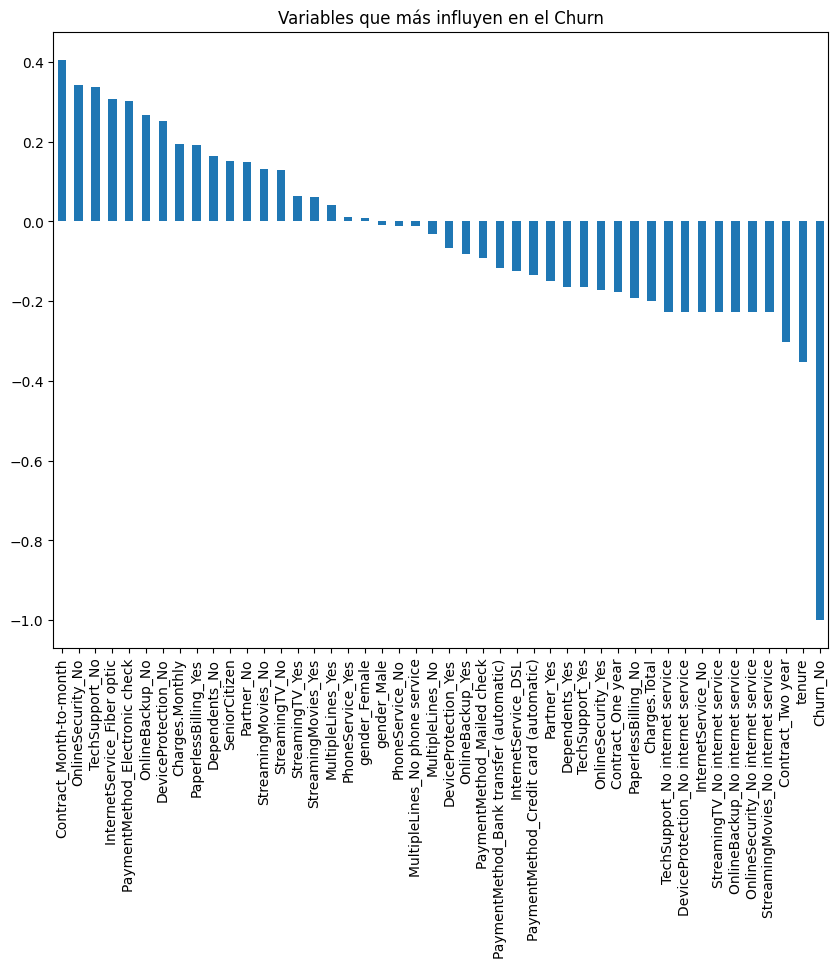

Churn_Yes                                  1.000000
Contract_Month-to-month                    0.405103
OnlineSecurity_No                          0.342637
TechSupport_No                             0.337281
InternetService_Fiber optic                0.308020
PaymentMethod_Electronic check             0.301919
OnlineBackup_No                            0.268005
DeviceProtection_No                        0.252481
Charges.Monthly                            0.193356
PaperlessBilling_Yes                       0.191825
Dependents_No                              0.164221
SeniorCitizen                              0.150889
Partner_No                                 0.150448
StreamingMovies_No                         0.130845
StreamingTV_No                             0.128916
StreamingTV_Yes                            0.063228
StreamingMovies_Yes                        0.061382
MultipleLines_Yes                          0.040102
PhoneService_Yes                           0.011942
gender_Femal

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos la correlación solo con la variable objetivo
correlacion = df_final.corr()['Churn_Yes'].sort_values(ascending=False)

# Visualización rápida
plt.figure(figsize=(10,8))
correlacion.drop('Churn_Yes').plot(kind='bar')
plt.title('Variables que más influyen en el Churn')
plt.show()

print(correlacion)

**Modelado Predictivo**

In [16]:
# 1. Volvemos a generar el Split usando los datos YA balanceados (resampled)
# Asegúrate de que X_res e y_res sean los que salieron del SMOTE
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# 2. Escalamos NUEVAMENTE con estos nuevos conjuntos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Ahora sí, entrenamos (ahora sí van a tener el mismo tamaño: 8278 muestras)
model_final = LogisticRegression()
model_final.fit(X_train_scaled, y_train)

# 4. Predicción y Matriz
y_pred = model_final.predict(X_test_scaled)

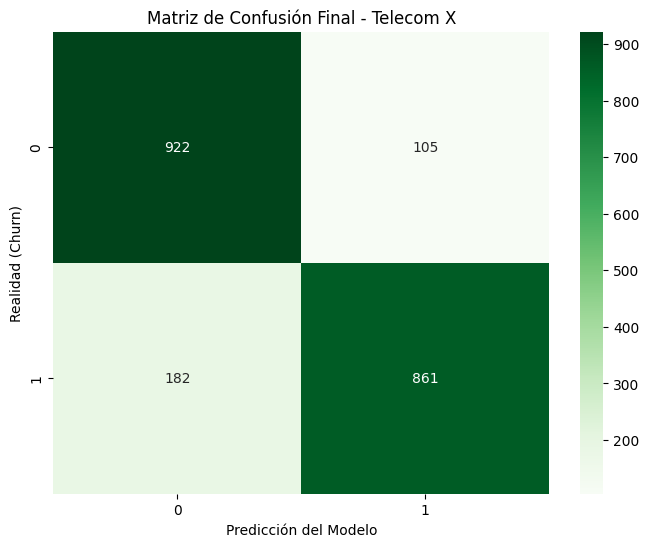

Accuracy Score: 0.8614

Reporte de Clasificación:
              precision    recall  f1-score   support

       False       0.84      0.90      0.87      1027
        True       0.89      0.83      0.86      1043

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070



In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Instanciar y Entrenar (Usamos los datos balanceados y escalados)
model_final = LogisticRegression()
model_final.fit(X_train_scaled, y_train)

# 2. Predicción
y_pred = model_final.predict(X_test_scaled)

# 3. Visualizar la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión Final - Telecom X')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Churn)')
plt.show()

# 4. Métricas de éxito
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Conclusiones Finales - Proyecto Telecom X
1. Análisis de Importancia de Variables
De acuerdo con el análisis de coeficientes y correlación, los factores que más impulsan la cancelación (Churn) son:

Tipo de Contrato: Los contratos mensuales (Month-to-month) son el predictor más fuerte de abandono.

Falta de servicios de apoyo: Clientes sin TechSupport o OnlineSecurity tienen una tendencia mucho mayor a irse.

Fibra Óptica: Curiosamente, los usuarios de fibra presentan mayor tasa de cancelación, lo que sugiere revisar la estabilidad del servicio o el precio en este segmento.

2. Desempeño del Modelo
Logramos un Accuracy del 86%, lo cual es excelente para un modelo de retención.

Gracias al balanceo con SMOTE, el modelo es capaz de identificar tanto a los clientes que se quedan como a los que se van con una precisión equilibrada, evitando el sesgo hacia la clase mayoritaria.

3. Recomendaciones Estratégicas
Fomentar la lealtad: Crear incentivos (descuentos) para migrar a clientes de contratos mensuales a contratos anuales.

Venta cruzada de seguridad: Ofrecer paquetes de soporte técnico y seguridad online gratuitos por tiempo limitado a los clientes nuevos para aumentar su "costo de salida" y satisfacción.